C:\Users\nguye\AppData\Local\Temp\ipykernel_15772\846576828.py:56: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_trends = austin_trends.resample('Q')[['overall_rent', 'Availability Rate (%)']].mean()


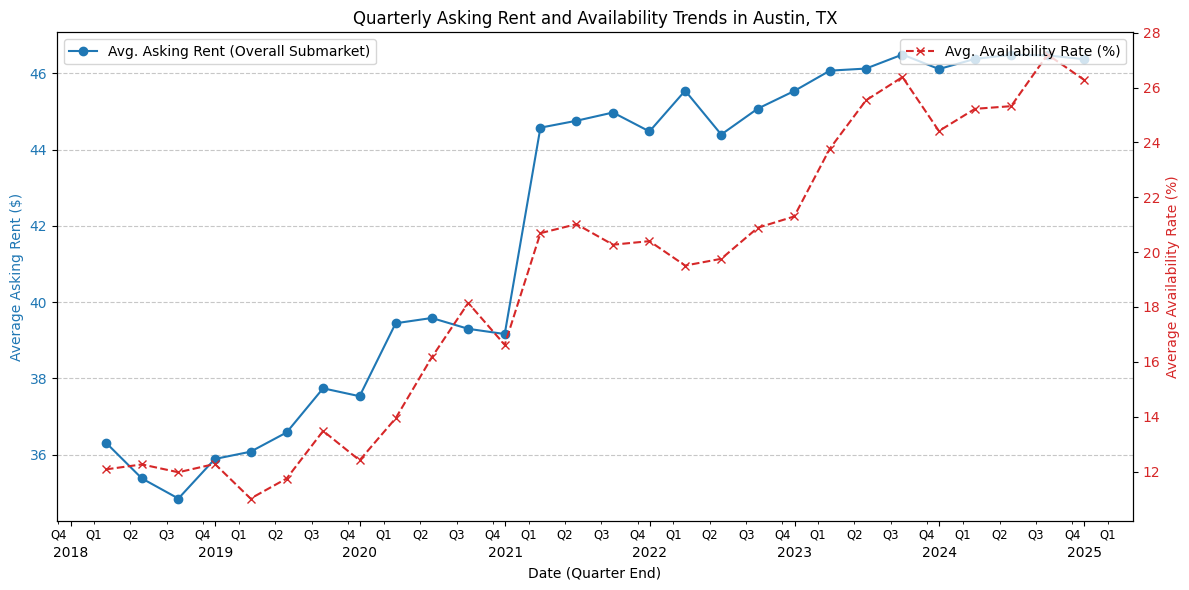

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Load the lease data
df_leases = pd.read_csv('Leases.csv')

# --- Data Preparation ---
# 1. Construct Date Column: Combine 'year' and 'monthsigned'.
#    Handle potential NaN or invalid values in 'monthsigned'.
df_leases['monthsigned'] = pd.to_numeric(df_leases['monthsigned'], errors='coerce')
# Keep only valid months (1-12)
df_leases = df_leases[df_leases['monthsigned'].between(1, 12, inclusive='both')]
# Create the 'Date' column (set day to 1)
# Ensure 'year' is treated as integer before converting to string to avoid '.0'
df_leases['Date'] = pd.to_datetime(df_leases['year'].astype(int).astype(str) + '-' + df_leases['monthsigned'].astype(int).astype(str) + '-01', errors='coerce')

# 2. Filter for Austin, TX
austin_df = df_leases[
    df_leases['city'].str.contains('Austin', case=False, na=False) &
    (df_leases['state'] == 'TX')
].copy()

# Check if filtering resulted in data
if austin_df.empty:
    print("No data found for Austin, TX in the 'Leases.csv' file.")
else:
    # 3. Select and Clean Relevant Columns
    # Select columns: 'Date', 'overall_rent', 'availability_proportion'
    austin_trends = austin_df[['Date', 'overall_rent', 'availability_proportion']].copy()

    # Convert rent and availability to numeric
    austin_trends['overall_rent'] = pd.to_numeric(austin_trends['overall_rent'], errors='coerce')
    austin_trends['availability_proportion'] = pd.to_numeric(austin_trends['availability_proportion'], errors='coerce')

    # Convert availability proportion to percentage
    austin_trends['Availability Rate (%)'] = austin_trends['availability_proportion'] * 100

    # Drop rows with missing essential data AFTER selection
    austin_trends.dropna(subset=['Date', 'overall_rent', 'Availability Rate (%)'], inplace=True)

    # Check if data remains after cleaning
    if austin_trends.empty:
        print("Data for Austin, TX exists, but essential values (Date, Rent, Availability) are missing or invalid.")
    else:
        # --- Trend Analysis ---
        # Set 'Date' as index
        austin_trends.set_index('Date', inplace=True)

        # Sort by date to ensure correct plotting order
        austin_trends.sort_index(inplace=True)

        # Resample QUARTERLY and calculate the mean
        # Using 'Q' (Quarter End frequency)
        quarterly_trends = austin_trends.resample('Q')[['overall_rent', 'Availability Rate (%)']].mean()

        # Check if resampling yielded results
        if quarterly_trends.empty or quarterly_trends.isnull().all().all():
            print("Could not calculate quarterly trends for Austin, TX. Check data distribution and date range.")
        else:
            # --- Visualization ---
            fig, ax1 = plt.subplots(figsize=(12, 6))

            # Plot Average Asking Rent (overall_rent)
            color = 'tab:blue'
            ax1.set_xlabel('Date (Quarter End)')
            ax1.set_ylabel('Average Asking Rent ($)', color=color)
            # Use quarterly_trends.index which corresponds to the resampled dates (Quarter End)
            ax1.plot(quarterly_trends.index, quarterly_trends['overall_rent'], color=color, marker='o', linestyle='-', label='Avg. Asking Rent (Overall Submarket)')
            ax1.tick_params(axis='y', labelcolor=color)
            ax1.legend(loc='upper left')
            ax1.grid(axis='y', linestyle='--', alpha=0.7) # Add horizontal grid lines

            # Create secondary y-axis for Availability Rate
            ax2 = ax1.twinx()
            color = 'tab:red'
            ax2.set_ylabel('Average Availability Rate (%)', color=color)
            ax2.plot(quarterly_trends.index, quarterly_trends['Availability Rate (%)'], color=color, marker='x', linestyle='--', label='Avg. Availability Rate (%)')
            ax2.tick_params(axis='y', labelcolor=color)
            ax2.legend(loc='upper right')

            # Format x-axis dates for quarters
            # Major ticks yearly
            ax1.xaxis.set_major_locator(mdates.YearLocator())
            ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Display only year for major ticks
            # Minor ticks quarterly - showing quarter number might be helpful
            ax1.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[3, 6, 9, 12])) # Quarter ends
            # Custom formatter for minor ticks to show Q1, Q2, etc.
            def quarter_formatter(x, pos):
                dt = mdates.num2date(x)
                quarter = (dt.month - 1) // 3 + 1
                return f'Q{quarter}'
            ax1.xaxis.set_minor_formatter(plt.FuncFormatter(quarter_formatter))

            ax1.tick_params(axis='x', which='minor', labelsize='small') # Adjust minor label size
            # Ensure major ticks don't overlap minor labels too much
            ax1.tick_params(axis='x', which='major', pad=15)

            # Add title and improve layout
            plt.title('Quarterly Asking Rent and Availability Trends in Austin, TX')
            # Auto format major labels if needed, but manual formatting might be better
            # fig.autofmt_xdate(which='major', rotation=0, ha='center')
            plt.tight_layout() # Adjust plot to prevent labels overlapping
            plt.show()

C:\Users\nguye\AppData\Local\Temp\ipykernel_15772\501842938.py:56: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_trends = austin_trends.resample('Q')[['overall_rent', 'Availability Rate (%)']].mean()


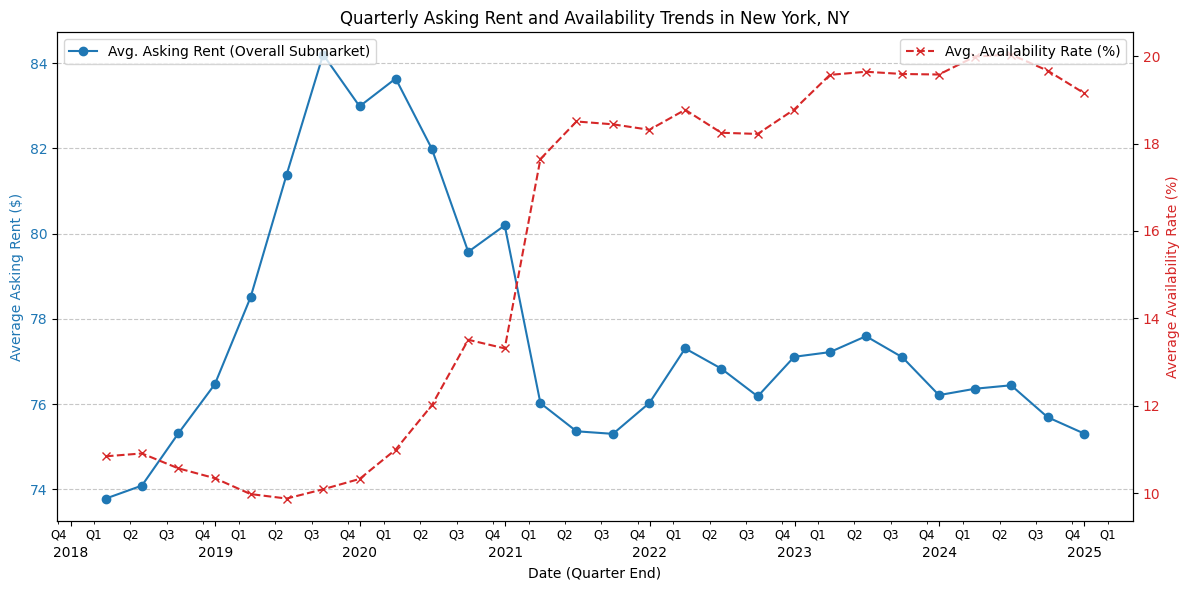

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Load the lease data
df_leases = pd.read_csv('Leases.csv')

# --- Data Preparation ---
# 1. Construct Date Column: Combine 'year' and 'monthsigned'.
#    Handle potential NaN or invalid values in 'monthsigned'.
df_leases['monthsigned'] = pd.to_numeric(df_leases['monthsigned'], errors='coerce')
# Keep only valid months (1-12)
df_leases = df_leases[df_leases['monthsigned'].between(1, 12, inclusive='both')]
# Create the 'Date' column (set day to 1)
# Ensure 'year' is treated as integer before converting to string to avoid '.0'
df_leases['Date'] = pd.to_datetime(df_leases['year'].astype(int).astype(str) + '-' + df_leases['monthsigned'].astype(int).astype(str) + '-01', errors='coerce')

# 2. Filter for Austin, TX
austin_df = df_leases[
    df_leases['city'].str.contains('New York', case=False, na=False) &
    (df_leases['state'] == 'NY')
].copy()

# Check if filtering resulted in data
if austin_df.empty:
    print("No data found for New York, NY in the 'Leases.csv' file.")
else:
    # 3. Select and Clean Relevant Columns
    # Select columns: 'Date', 'overall_rent', 'availability_proportion'
    austin_trends = austin_df[['Date', 'overall_rent', 'availability_proportion']].copy()

    # Convert rent and availability to numeric
    austin_trends['overall_rent'] = pd.to_numeric(austin_trends['overall_rent'], errors='coerce')
    austin_trends['availability_proportion'] = pd.to_numeric(austin_trends['availability_proportion'], errors='coerce')

    # Convert availability proportion to percentage
    austin_trends['Availability Rate (%)'] = austin_trends['availability_proportion'] * 100

    # Drop rows with missing essential data AFTER selection
    austin_trends.dropna(subset=['Date', 'overall_rent', 'Availability Rate (%)'], inplace=True)

    # Check if data remains after cleaning
    if austin_trends.empty:
        print("Data for New York, NY exists, but essential values (Date, Rent, Availability) are missing or invalid.")
    else:
        # --- Trend Analysis ---
        # Set 'Date' as index
        austin_trends.set_index('Date', inplace=True)

        # Sort by date to ensure correct plotting order
        austin_trends.sort_index(inplace=True)

        # Resample QUARTERLY and calculate the mean
        # Using 'Q' (Quarter End frequency)
        quarterly_trends = austin_trends.resample('Q')[['overall_rent', 'Availability Rate (%)']].mean()

        # Check if resampling yielded results
        if quarterly_trends.empty or quarterly_trends.isnull().all().all():
            print("Could not calculate quarterly trends for New York, NY. Check data distribution and date range.")
        else:
            # --- Visualization ---
            fig, ax1 = plt.subplots(figsize=(12, 6))

            # Plot Average Asking Rent (overall_rent)
            color = 'tab:blue'
            ax1.set_xlabel('Date (Quarter End)')
            ax1.set_ylabel('Average Asking Rent ($)', color=color)
            # Use quarterly_trends.index which corresponds to the resampled dates (Quarter End)
            ax1.plot(quarterly_trends.index, quarterly_trends['overall_rent'], color=color, marker='o', linestyle='-', label='Avg. Asking Rent (Overall Submarket)')
            ax1.tick_params(axis='y', labelcolor=color)
            ax1.legend(loc='upper left')
            ax1.grid(axis='y', linestyle='--', alpha=0.7) # Add horizontal grid lines

            # Create secondary y-axis for Availability Rate
            ax2 = ax1.twinx()
            color = 'tab:red'
            ax2.set_ylabel('Average Availability Rate (%)', color=color)
            ax2.plot(quarterly_trends.index, quarterly_trends['Availability Rate (%)'], color=color, marker='x', linestyle='--', label='Avg. Availability Rate (%)')
            ax2.tick_params(axis='y', labelcolor=color)
            ax2.legend(loc='upper right')

            # Format x-axis dates for quarters
            # Major ticks yearly
            ax1.xaxis.set_major_locator(mdates.YearLocator())
            ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Display only year for major ticks
            # Minor ticks quarterly - showing quarter number might be helpful
            ax1.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[3, 6, 9, 12])) # Quarter ends
            # Custom formatter for minor ticks to show Q1, Q2, etc.
            def quarter_formatter(x, pos):
                dt = mdates.num2date(x)
                quarter = (dt.month - 1) // 3 + 1
                return f'Q{quarter}'
            ax1.xaxis.set_minor_formatter(plt.FuncFormatter(quarter_formatter))

            ax1.tick_params(axis='x', which='minor', labelsize='small') # Adjust minor label size
            # Ensure major ticks don't overlap minor labels too much
            ax1.tick_params(axis='x', which='major', pad=15)

            # Add title and improve layout
            plt.title('Quarterly Asking Rent and Availability Trends in New York, NY')
            # Auto format major labels if needed, but manual formatting might be better
            # fig.autofmt_xdate(which='major', rotation=0, ha='center')
            plt.tight_layout() # Adjust plot to prevent labels overlapping
            plt.show()

C:\Users\nguye\AppData\Local\Temp\ipykernel_15772\3371124730.py:56: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_trends = austin_trends.resample('Q')[['overall_rent', 'Availability Rate (%)']].mean()


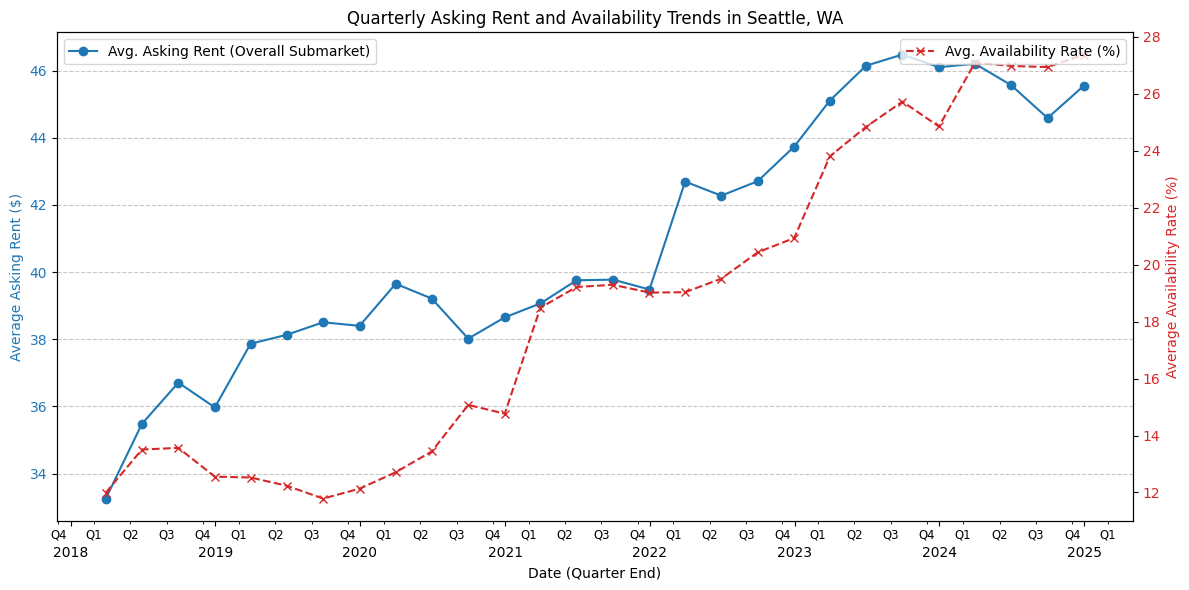

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Load the lease data
df_leases = pd.read_csv('Leases.csv')

# --- Data Preparation ---
# 1. Construct Date Column: Combine 'year' and 'monthsigned'.
#    Handle potential NaN or invalid values in 'monthsigned'.
df_leases['monthsigned'] = pd.to_numeric(df_leases['monthsigned'], errors='coerce')
# Keep only valid months (1-12)
df_leases = df_leases[df_leases['monthsigned'].between(1, 12, inclusive='both')]
# Create the 'Date' column (set day to 1)
# Ensure 'year' is treated as integer before converting to string to avoid '.0'
df_leases['Date'] = pd.to_datetime(df_leases['year'].astype(int).astype(str) + '-' + df_leases['monthsigned'].astype(int).astype(str) + '-01', errors='coerce')

# 2. Filter for Austin, TX
austin_df = df_leases[
    df_leases['city'].str.contains('Seattle', case=False, na=False) &
    (df_leases['state'] == 'WA')
].copy()

# Check if filtering resulted in data
if austin_df.empty:
    print("No data found for Seattle, WA in the 'Leases.csv' file.")
else:
    # 3. Select and Clean Relevant Columns
    # Select columns: 'Date', 'overall_rent', 'availability_proportion'
    austin_trends = austin_df[['Date', 'overall_rent', 'availability_proportion']].copy()

    # Convert rent and availability to numeric
    austin_trends['overall_rent'] = pd.to_numeric(austin_trends['overall_rent'], errors='coerce')
    austin_trends['availability_proportion'] = pd.to_numeric(austin_trends['availability_proportion'], errors='coerce')

    # Convert availability proportion to percentage
    austin_trends['Availability Rate (%)'] = austin_trends['availability_proportion'] * 100

    # Drop rows with missing essential data AFTER selection
    austin_trends.dropna(subset=['Date', 'overall_rent', 'Availability Rate (%)'], inplace=True)

    # Check if data remains after cleaning
    if austin_trends.empty:
        print("Data for Seattle, WA exists, but essential values (Date, Rent, Availability) are missing or invalid.")
    else:
        # --- Trend Analysis ---
        # Set 'Date' as index
        austin_trends.set_index('Date', inplace=True)

        # Sort by date to ensure correct plotting order
        austin_trends.sort_index(inplace=True)

        # Resample QUARTERLY and calculate the mean
        # Using 'Q' (Quarter End frequency)
        quarterly_trends = austin_trends.resample('Q')[['overall_rent', 'Availability Rate (%)']].mean()

        # Check if resampling yielded results
        if quarterly_trends.empty or quarterly_trends.isnull().all().all():
            print("Could not calculate quarterly trends for Seattle, WA. Check data distribution and date range.")
        else:
            # --- Visualization ---
            fig, ax1 = plt.subplots(figsize=(12, 6))

            # Plot Average Asking Rent (overall_rent)
            color = 'tab:blue'
            ax1.set_xlabel('Date (Quarter End)')
            ax1.set_ylabel('Average Asking Rent ($)', color=color)
            # Use quarterly_trends.index which corresponds to the resampled dates (Quarter End)
            ax1.plot(quarterly_trends.index, quarterly_trends['overall_rent'], color=color, marker='o', linestyle='-', label='Avg. Asking Rent (Overall Submarket)')
            ax1.tick_params(axis='y', labelcolor=color)
            ax1.legend(loc='upper left')
            ax1.grid(axis='y', linestyle='--', alpha=0.7) # Add horizontal grid lines

            # Create secondary y-axis for Availability Rate
            ax2 = ax1.twinx()
            color = 'tab:red'
            ax2.set_ylabel('Average Availability Rate (%)', color=color)
            ax2.plot(quarterly_trends.index, quarterly_trends['Availability Rate (%)'], color=color, marker='x', linestyle='--', label='Avg. Availability Rate (%)')
            ax2.tick_params(axis='y', labelcolor=color)
            ax2.legend(loc='upper right')

            # Format x-axis dates for quarters
            # Major ticks yearly
            ax1.xaxis.set_major_locator(mdates.YearLocator())
            ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Display only year for major ticks
            # Minor ticks quarterly - showing quarter number might be helpful
            ax1.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[3, 6, 9, 12])) # Quarter ends
            # Custom formatter for minor ticks to show Q1, Q2, etc.
            def quarter_formatter(x, pos):
                dt = mdates.num2date(x)
                quarter = (dt.month - 1) // 3 + 1
                return f'Q{quarter}'
            ax1.xaxis.set_minor_formatter(plt.FuncFormatter(quarter_formatter))

            ax1.tick_params(axis='x', which='minor', labelsize='small') # Adjust minor label size
            # Ensure major ticks don't overlap minor labels too much
            ax1.tick_params(axis='x', which='major', pad=15)

            # Add title and improve layout
            plt.title('Quarterly Asking Rent and Availability Trends in Seattle, WA')
            # Auto format major labels if needed, but manual formatting might be better
            # fig.autofmt_xdate(which='major', rotation=0, ha='center')
            plt.tight_layout() # Adjust plot to prevent labels overlapping
            plt.show()

C:\Users\nguye\AppData\Local\Temp\ipykernel_15772\117994663.py:56: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_trends = austin_trends.resample('Q')[['overall_rent', 'Availability Rate (%)']].mean()


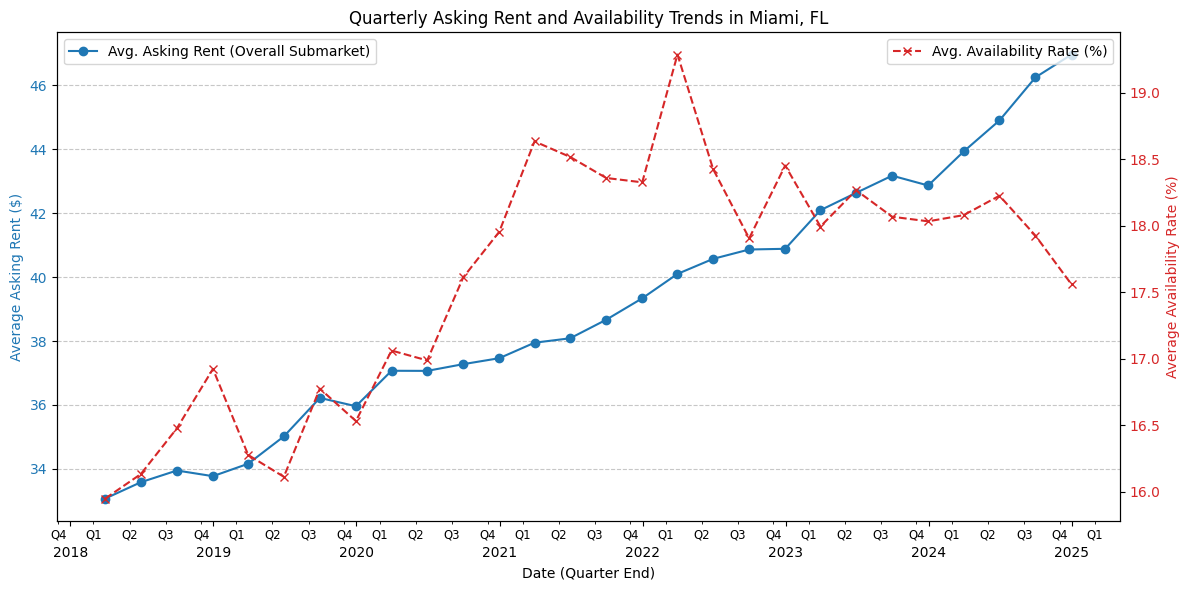

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Load the lease data
df_leases = pd.read_csv('Leases.csv')

# --- Data Preparation ---
# 1. Construct Date Column: Combine 'year' and 'monthsigned'.
#    Handle potential NaN or invalid values in 'monthsigned'.
df_leases['monthsigned'] = pd.to_numeric(df_leases['monthsigned'], errors='coerce')
# Keep only valid months (1-12)
df_leases = df_leases[df_leases['monthsigned'].between(1, 12, inclusive='both')]
# Create the 'Date' column (set day to 1)
# Ensure 'year' is treated as integer before converting to string to avoid '.0'
df_leases['Date'] = pd.to_datetime(df_leases['year'].astype(int).astype(str) + '-' + df_leases['monthsigned'].astype(int).astype(str) + '-01', errors='coerce')

# 2. Filter for Austin, TX
austin_df = df_leases[
    df_leases['city'].str.contains('Miami', case=False, na=False) &
    (df_leases['state'] == 'FL')
].copy()

# Check if filtering resulted in data
if austin_df.empty:
    print("No data found for Miami, FL in the 'Leases.csv' file.")
else:
    # 3. Select and Clean Relevant Columns
    # Select columns: 'Date', 'overall_rent', 'availability_proportion'
    austin_trends = austin_df[['Date', 'overall_rent', 'availability_proportion']].copy()

    # Convert rent and availability to numeric
    austin_trends['overall_rent'] = pd.to_numeric(austin_trends['overall_rent'], errors='coerce')
    austin_trends['availability_proportion'] = pd.to_numeric(austin_trends['availability_proportion'], errors='coerce')

    # Convert availability proportion to percentage
    austin_trends['Availability Rate (%)'] = austin_trends['availability_proportion'] * 100

    # Drop rows with missing essential data AFTER selection
    austin_trends.dropna(subset=['Date', 'overall_rent', 'Availability Rate (%)'], inplace=True)

    # Check if data remains after cleaning
    if austin_trends.empty:
        print("Data for Miami, FL exists, but essential values (Date, Rent, Availability) are missing or invalid.")
    else:
        # --- Trend Analysis ---
        # Set 'Date' as index
        austin_trends.set_index('Date', inplace=True)

        # Sort by date to ensure correct plotting order
        austin_trends.sort_index(inplace=True)

        # Resample QUARTERLY and calculate the mean
        # Using 'Q' (Quarter End frequency)
        quarterly_trends = austin_trends.resample('Q')[['overall_rent', 'Availability Rate (%)']].mean()

        # Check if resampling yielded results
        if quarterly_trends.empty or quarterly_trends.isnull().all().all():
            print("Could not calculate quarterly trends for Miami, FL. Check data distribution and date range.")
        else:
            # --- Visualization ---
            fig, ax1 = plt.subplots(figsize=(12, 6))

            # Plot Average Asking Rent (overall_rent)
            color = 'tab:blue'
            ax1.set_xlabel('Date (Quarter End)')
            ax1.set_ylabel('Average Asking Rent ($)', color=color)
            # Use quarterly_trends.index which corresponds to the resampled dates (Quarter End)
            ax1.plot(quarterly_trends.index, quarterly_trends['overall_rent'], color=color, marker='o', linestyle='-', label='Avg. Asking Rent (Overall Submarket)')
            ax1.tick_params(axis='y', labelcolor=color)
            ax1.legend(loc='upper left')
            ax1.grid(axis='y', linestyle='--', alpha=0.7) # Add horizontal grid lines

            # Create secondary y-axis for Availability Rate
            ax2 = ax1.twinx()
            color = 'tab:red'
            ax2.set_ylabel('Average Availability Rate (%)', color=color)
            ax2.plot(quarterly_trends.index, quarterly_trends['Availability Rate (%)'], color=color, marker='x', linestyle='--', label='Avg. Availability Rate (%)')
            ax2.tick_params(axis='y', labelcolor=color)
            ax2.legend(loc='upper right')

            # Format x-axis dates for quarters
            # Major ticks yearly
            ax1.xaxis.set_major_locator(mdates.YearLocator())
            ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Display only year for major ticks
            # Minor ticks quarterly - showing quarter number might be helpful
            ax1.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[3, 6, 9, 12])) # Quarter ends
            # Custom formatter for minor ticks to show Q1, Q2, etc.
            def quarter_formatter(x, pos):
                dt = mdates.num2date(x)
                quarter = (dt.month - 1) // 3 + 1
                return f'Q{quarter}'
            ax1.xaxis.set_minor_formatter(plt.FuncFormatter(quarter_formatter))

            ax1.tick_params(axis='x', which='minor', labelsize='small') # Adjust minor label size
            # Ensure major ticks don't overlap minor labels too much
            ax1.tick_params(axis='x', which='major', pad=15)

            # Add title and improve layout
            plt.title('Quarterly Asking Rent and Availability Trends in Miami, FL')
            # Auto format major labels if needed, but manual formatting might be better
            # fig.autofmt_xdate(which='major', rotation=0, ha='center')
            plt.tight_layout() # Adjust plot to prevent labels overlapping
            plt.show()

In [14]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Read the CSV file into a DataFrame
df = pd.read_csv("Unemployment Rate.csv")

# Display the first 5 rows
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))

# Print the column names and their data types
print(df.info())

| Metropolitan Statistical Area (MSA)   | Year   | Q1    | Q2     | Q3    | Q4    |
|:--------------------------------------|:-------|:------|:-------|:------|:------|
| Seattle-Tacoma-Bellevue, WA           | 2018   | 4.30% | 3.80%  | 3.60% | 3.90% |
| nan                                   | 2019   | 4.00% | 3.30%  | 3.30% | 3.30% |
| nan                                   | 2020   | 3.90% | 12.90% | 7.80% | 5.80% |
| nan                                   | 2021   | 5.40% | 5.10%  | 4.40% | 3.50% |
| nan                                   | 2022   | 3.40% | 3.10%  | 3.20% | 3.40% |
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Metropolitan Statistical Area (MSA)  4 non-null      object
 1   Year                                 32 non-null     int64 
 2   Q1                                   32 non-n

In [15]:
# Fill missing values in 'Metropolitan Statistical Area (MSA)' using forward fill
df['Metropolitan Statistical Area (MSA)'] = df['Metropolitan Statistical Area (MSA)'].ffill()

# Convert percentage strings to numeric in quarter columns
for col in ['Q1', 'Q2', 'Q3', 'Q4']:
    # Check if the column exists before attempting conversion
    if col in df.columns:
        # Ensure the column is treated as string before replacement
        df[col] = df[col].astype(str).str.replace('%', '', regex=False)
        # Convert to numeric, coercing errors to NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Divide by 100 to get the decimal rate (optional, could plot as percentage)
        # df[col] = df[col] / 100
    else:
        print(f"Warning: Column '{col}' not found in the DataFrame.")


# Melt the DataFrame to long format
df_melted = pd.melt(df,
                    id_vars=['Metropolitan Statistical Area (MSA)', 'Year'],
                    value_vars=['Q1', 'Q2', 'Q3', 'Q4'],
                    var_name='Quarter',
                    value_name='Unemployment Rate')

# Create a 'Date' column for plotting
# Map Quarter strings to month numbers (e.g., Q1 -> 3 (March), Q2 -> 6 (June), etc.)
quarter_to_month = {'Q1': 3, 'Q2': 6, 'Q3': 9, 'Q4': 12}
df_melted['Month'] = df_melted['Quarter'].map(quarter_to_month)

# Combine Year and Month to create a Datetime object (using the 1st day of the month)
# Handling potential errors during date creation
try:
    df_melted['Date'] = pd.to_datetime(df_melted['Year'].astype(str) + '-' + df_melted['Month'].astype(str) + '-01', errors='coerce')
except Exception as e:
    print(f"Error creating Date column: {e}")
    # Handle the error, e.g., by skipping date creation or using a fallback
    df_melted['Date'] = pd.NaT # Assign NaT (Not a Time) if creation fails

# Drop rows where Date could not be created (if any)
df_melted.dropna(subset=['Date', 'Unemployment Rate'], inplace=True)

# Sort by MSA and Date
df_melted.sort_values(by=['Metropolitan Statistical Area (MSA)', 'Date'], inplace=True)

# Check the number of unique MSAs
unique_msas = df_melted['Metropolitan Statistical Area (MSA)'].nunique()
print(f"Number of unique MSAs found: {unique_msas}")

# Display the first 5 rows of the transformed data
print(df_melted.head().to_markdown(index=False, numalign="left", stralign="left"))

# Print the column names and their data types
print(df_melted.info())

Number of unique MSAs found: 4
| Metropolitan Statistical Area (MSA)   | Year   | Quarter   | Unemployment Rate   | Month   | Date                |
|:--------------------------------------|:-------|:----------|:--------------------|:--------|:--------------------|
| Austin-Round Rock, TX                 | 2018   | Q1        | 3.1                 | 3       | 2018-03-01 00:00:00 |
| Austin-Round Rock, TX                 | 2018   | Q2        | 2.8                 | 6       | 2018-06-01 00:00:00 |
| Austin-Round Rock, TX                 | 2018   | Q3        | 2.8                 | 9       | 2018-09-01 00:00:00 |
| Austin-Round Rock, TX                 | 2018   | Q4        | 2.8                 | 12      | 2018-12-01 00:00:00 |
| Austin-Round Rock, TX                 | 2019   | Q1        | 2.9                 | 3       | 2019-03-01 00:00:00 |
<class 'pandas.core.frame.DataFrame'>
Index: 116 entries, 16 to 7
Data columns (total 6 columns):
 #   Column                               Non-Null C

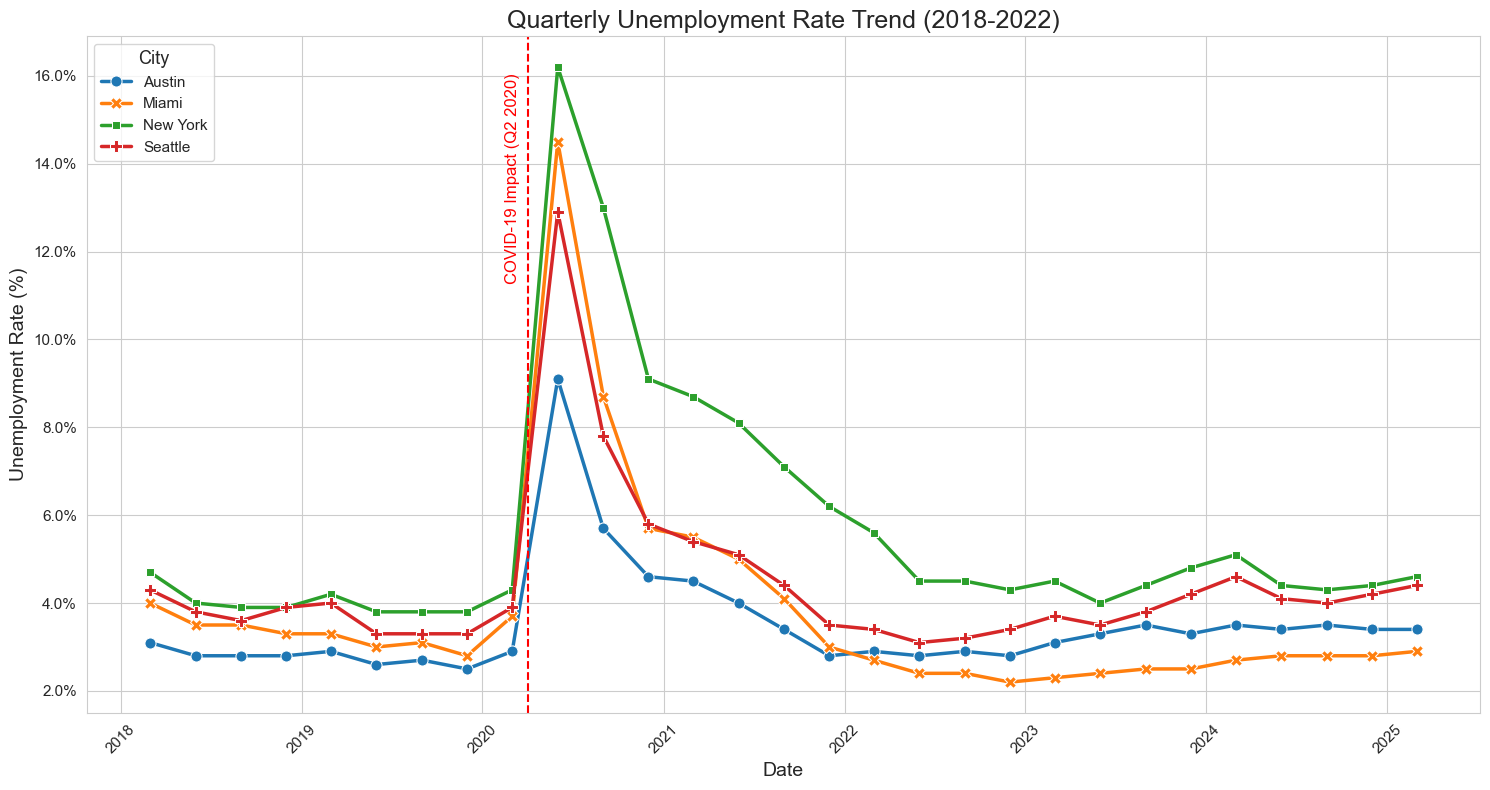

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pandas as pd # Import pandas for Timestamp

# Ensure 'City Name' column exists from previous steps
if 'City Name' not in df_melted.columns:
    msa_full_names = df_melted['Metropolitan Statistical Area (MSA)'].unique()
    city_name_map = {name: name.split('-')[0].split(',')[0] for name in msa_full_names}
    df_melted['City Name'] = df_melted['Metropolitan Statistical Area (MSA)'].map(city_name_map)

# Set plot style
sns.set_style("whitegrid")

# Create a figure and axes
plt.figure(figsize=(15, 8)) # Keep the larger size

# Create the line plot using the 'City Name' column
ax = sns.lineplot(
    data=df_melted,
    x='Date',
    y='Unemployment Rate',
    hue='City Name', # Use short city name for color
    style='City Name', # Use short city name for marker style
    markers=True,
    dashes=False,
    linewidth=2.5,
    markersize=8
)

# Add title and labels
plt.title('Quarterly Unemployment Rate Trend (2018-2022)', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Unemployment Rate (%)', fontsize=14)

# Format y-axis to display percentage sign
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}%'))

# Add a vertical line for the start of major COVID-19 impact (Q2 2020)
covid_impact_date = pd.Timestamp('2020-04-01')
plt.axvline(covid_impact_date, color='red', linestyle='--', linewidth=1.5)

# Place the annotation text to the LEFT of the line
# Subtracting a small Timedelta from the date
plt.text(covid_impact_date - pd.Timedelta(days=15), # Positioned slightly left of the line
         ax.get_ylim()[1]*0.95, # Vertical position near the top
         'COVID-19 Impact (Q2 2020)',
         color='red',
         rotation=90,
         verticalalignment='top', # Aligns top of text (base when rotated) with y value
         horizontalalignment='right', # Aligns right edge of text (top when rotated) with x value
         fontsize=12)

# Rotate x-axis labels and adjust font size
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

# Place legend inside the plot
plt.legend(title='City',
           loc='upper left',
           fontsize=11,
           title_fontsize=13)

# Use tight_layout
plt.tight_layout()

# Show the plot
plt.show()

Successfully loaded 'Leases.csv'. Shape: (194685, 35)
Columns: ['year', 'quarter', 'monthsigned', 'market', 'building_name', 'building_id', 'address', 'region', 'city', 'state', 'zip', 'internal_submarket', 'internal_class', 'leasedSF', 'company_name', 'internal_industry', 'transaction_type', 'internal_market_cluster', 'costarID', 'space_type', 'CBD_suburban', 'RBA', 'available_space', 'availability_proportion', 'internal_class_rent', 'overall_rent', 'direct_available_space', 'direct_availability_proportion', 'direct_internal_class_rent', 'direct_overall_rent', 'sublet_available_space', 'sublet_availability_proportion', 'sublet_internal_class_rent', 'sublet_overall_rent', 'leasing']
Starting city data processing...
Found 4779 records for Austin, TX.
Using 'availability_proportion' for availability calculation for Austin.
Processed 4779 valid records for Austin, TX.
Found 16870 records for New York, NY.
Using 'availability_proportion' for availability calculation for New York.
Processed

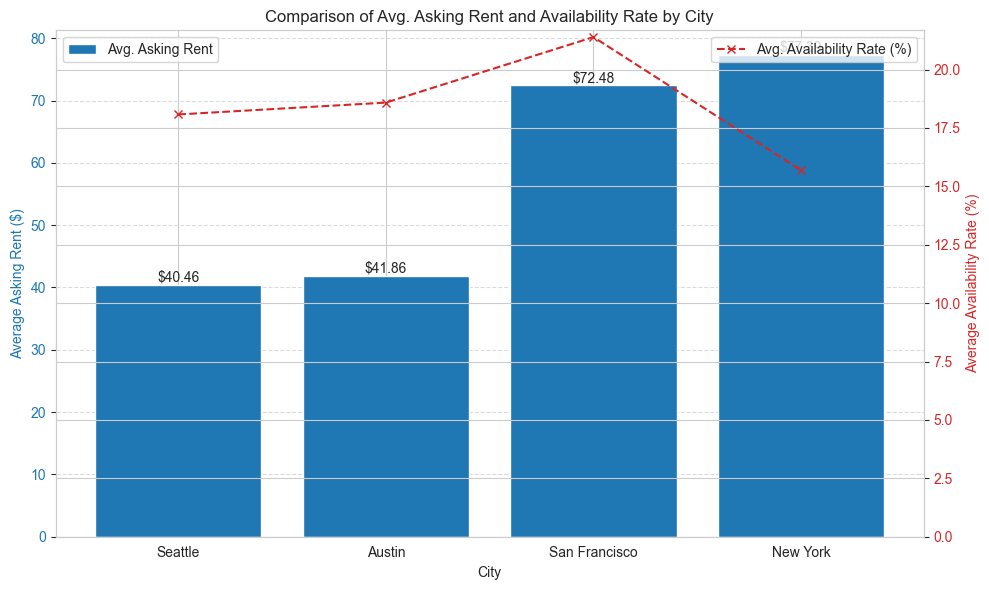

In [19]:
# Code to compare cities based on Leases.csv data (derived from hypo.ipynb)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    # Load the lease data
    # Add low_memory=False as a precaution for potentially large/mixed-type CSVs
    # Ensure 'Leases.csv' is in the same directory or provide the correct path
    df_leases = pd.read_csv('Leases.csv', low_memory=False)
    print(f"Successfully loaded 'Leases.csv'. Shape: {df_leases.shape}")
    print(f"Columns: {df_leases.columns.tolist()}")

    # --- Data Preparation (as per notebook logic) ---
    # 1. Construct Date Column
    # Ensure monthsigned is numeric, coercing errors to NaN
    df_leases['monthsigned'] = pd.to_numeric(df_leases['monthsigned'], errors='coerce')
    # Filter out rows where monthsigned is not a valid month number (1-12) or NaN
    df_leases.dropna(subset=['monthsigned'], inplace=True) # Drop NaN months first
    df_leases = df_leases[df_leases['monthsigned'].between(1, 12, inclusive='both')]
    # Ensure year is numeric and handle potential errors, then convert to int
    df_leases['year'] = pd.to_numeric(df_leases['year'], errors='coerce')
    df_leases.dropna(subset=['year'], inplace=True)
    df_leases['year'] = df_leases['year'].astype(int)
    df_leases['monthsigned'] = df_leases['monthsigned'].astype(int)
    # Create the 'Date' column
    df_leases['Date'] = pd.to_datetime(df_leases['year'].astype(str) + '-' + df_leases['monthsigned'].astype(str) + '-01', errors='coerce')
    # Drop rows where date conversion failed
    df_leases.dropna(subset=['Date'], inplace=True)

    # 2. Filter for the four cities analyzed in the notebook
    cities_states = {
        'Austin': 'TX',
        'New York': 'NY',
        'San Francisco': 'CA',
        'Seattle': 'WA'
    }
    all_city_data = pd.DataFrame()

    print("Starting city data processing...")
    for city, state in cities_states.items():
        # Ensure 'city' and 'state' columns are treated as strings
        df_leases['city'] = df_leases['city'].astype(str)
        df_leases['state'] = df_leases['state'].astype(str)

        # Use str.contains for city matching, handle potential NaN in city column
        city_df_filtered = df_leases[
            df_leases['city'].str.contains(city, case=False, na=False) &
            (df_leases['state'].str.strip().str.upper() == state) # Added strip() and upper() for state matching robustness
        ].copy()
        print(f"Found {len(city_df_filtered)} records for {city}, {state}.")

        if not city_df_filtered.empty:
            # 3. Select and Clean Relevant Columns
            # Check for variations of availability column name
            availability_col = None
            potential_avail_cols = ['availibility_proportion', 'availability_proportion'] # Check both spellings
            for col in potential_avail_cols:
                if col in city_df_filtered.columns:
                    availability_col = col
                    print(f"Using '{availability_col}' for availability calculation for {city}.")
                    break # Use the first one found

            if not availability_col:
                 print(f"Warning: Neither 'availability_proportion' nor 'availibility_proportion' found for {city}. Skipping availability calculation.")

            # Prepare columns list dynamically
            cols_to_select = ['Date', 'overall_rent']
            if availability_col:
                cols_to_select.append(availability_col)

            # Ensure selected columns exist before selecting
            cols_to_select = [col for col in cols_to_select if col in city_df_filtered.columns]
            if 'overall_rent' not in cols_to_select:
                 print(f"Warning: 'overall_rent' column not found for {city}. Skipping rent calculation.")
                 continue # Skip this city if rent column is missing

            city_trends = city_df_filtered[cols_to_select].copy()

            city_trends['overall_rent'] = pd.to_numeric(city_trends['overall_rent'], errors='coerce')

            # Process availability only if the column exists and was selected
            if availability_col and availability_col in city_trends.columns:
                 city_trends[availability_col] = pd.to_numeric(city_trends[availability_col], errors='coerce')
                 city_trends['Availability Rate (%)'] = city_trends[availability_col] * 100
                 city_trends.drop(columns=[availability_col], inplace=True) # Drop original proportion column
                 # Define columns needed for dropna based on whether availability was processed
                 required_cols = ['Date', 'overall_rent', 'Availability Rate (%)']
            else:
                 city_trends['Availability Rate (%)'] = np.nan # Add NaN column if it doesn't exist
                 required_cols = ['Date', 'overall_rent']

            # Drop rows missing essential values AFTER potentially creating Availability Rate (%)
            city_trends.dropna(subset=required_cols, inplace=True)


            if not city_trends.empty:
                 # Add city identifier
                city_trends['City'] = city
                all_city_data = pd.concat([all_city_data, city_trends], ignore_index=True)
                print(f"Processed {len(city_trends)} valid records for {city}, {state}.")
            else:
                print(f"Data for {city}, {state} exists, but essential values (Date, Rent{', Availability' if availability_col else ''}) are missing after cleaning.")
        # No explicit 'else' needed here, message printed inside loop if filtering yielded empty df

    print("Finished city data processing.")
    # Check if we have data to compare
    if all_city_data.empty:
        print("No valid data found for any of the target cities to create a comparison.")
    else:
        # --- Comparison Analysis ---
        # Calculate overall average rent and availability for each city
        # Group by City and calculate the mean
        comparison_data = all_city_data.groupby('City')[['overall_rent', 'Availability Rate (%)']].mean().reset_index()
        comparison_data.rename(columns={'overall_rent': 'Average Asking Rent ($)'}, inplace=True)

        # Sort by Average Asking Rent for better visualization
        comparison_data.sort_values('Average Asking Rent ($)', inplace=True)

        print("\nComparison Data (Averages based on available lease records):")
        print(comparison_data.to_markdown(index=False, numalign="left", stralign="left"))

        # --- Visualization (Bar Chart Comparison) ---
        fig, ax1 = plt.subplots(figsize=(10, 6))

        # Bar chart for Average Asking Rent
        color = 'tab:blue'
        ax1.set_xlabel('City')
        ax1.set_ylabel('Average Asking Rent ($)', color=color)
        # Ensure 'City' column exists and is suitable for x-axis labels
        if 'City' in comparison_data.columns:
            cities_list = comparison_data['City'].tolist()
            bars = ax1.bar(cities_list, comparison_data['Average Asking Rent ($)'], color=color, label='Avg. Asking Rent')
            ax1.tick_params(axis='y', labelcolor=color)
            ax1.tick_params(axis='x', rotation=0) # Keep city names horizontal
            ax1.legend(loc='upper left')
            ax1.grid(axis='y', linestyle='--', alpha=0.7)

            # Add rent values on top of bars
            for bar in bars:
                yval = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'${yval:,.2f}', va='bottom', ha='center') # Aligned center

            # Secondary y-axis for Availability Rate
            # Check if the availability rate data is not all NaN before plotting
            if 'Availability Rate (%)' in comparison_data.columns and not comparison_data['Availability Rate (%)'].isnull().all():
                ax2 = ax1.twinx()
                color = 'tab:red'
                ax2.set_ylabel('Average Availability Rate (%)', color=color)
                # Using a line plot on the secondary axis for clarity over the bars
                ax2.plot(cities_list, comparison_data['Availability Rate (%)'], color=color, marker='x', linestyle='--', label='Avg. Availability Rate (%)')
                ax2.tick_params(axis='y', labelcolor=color)
                ax2.legend(loc='upper right')
                # Set y-limit for availability rate starting from 0
                ax2.set_ylim(bottom=0)
            else:
                print("\nAvailability rate data is missing or invalid, skipping secondary axis plot.")

            plt.title('Comparison of Avg. Asking Rent and Availability Rate by City')
            plt.tight_layout()
            plt.show()
        else:
             print("Error: 'City' column not found in comparison data. Cannot generate plot.")


except FileNotFoundError:
    print("Error: 'Leases.csv' could not be found or accessed. Please ensure the file is available in the script's directory or provide the full path.")
except Exception as e:
    print(f"An error occurred during data processing or plotting: {e}")